In [ ]:
import io
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Dados Banco Central do Brasil

In [ ]:
df_bcb = pd.read_parquet("data/processed/bcb_credit_sample.parquet")
df_bcb.head()

,data_base,segmento,cliente,cnae_ocupacao,porte,modalidade,submodalidade,origem,indexador,numero_de_operacoes,...,a_vencer_de_1801_ate_5400_dias,a_vencer_acima_de_5400_dias,carteira_a_vencer,vencido_de_15_ate_90_dias,vencido_acima_de_90_dias,carteira_vencida,carteira_ativa,carteira_inadimplencia,ativo_problematico,target_default
0,2026-06-30,Banco,PF,Outros,Mais de 1 a 2 salários mínimos,Financiamentos rurais (ex-financiamentos rura...,Investimento,Sem destinação específica,Prefixado,46,...,2225100.48,300536.24,6017383.26,0.00,0.00,0.00,6017383.26,0.00,300536.24,0
1,2026-01-31,Banco,PF,Outros,Até 1 salário mínimo,Financiamentos rurais (ex-financiamentos rura...,Custeio,Sem destinação específica,Outros indexadores,1,...,0.00,0.00,67302.24,0.00,0.00,0.00,67302.24,0.00,67302.24,0
2,2025-10-31,Banco,PJ,Alojamento e alimentação,Micro,Adiantamentos a depositantes,Adiantamentos a depositantes,Sem destinação específica,Prefixado,11,...,0.00,629.87,635.01,0.04,49980.64,49980.68,50615.69,49980.64,50610.55,1
3,2025-10-31,Outros,PF,Outros,Mais de 10 a 20 salários mínimos,Financiamentos imobiliários,Financiamento habitacional  exceto SFH,Com destinação específica,Prefixado,-1,...,0.00,0.00,61044.68,0.00,0.00,0.00,61044.68,0.00,0.00,0
4,2026-05-31,Banco,PF,Servidor ou empregado público,Até 1 salário mínimo,Empréstimos,"Cartão de crédito - compra, fatura parcelada o...",Sem destinação específica,Prefixado,662,...,38656.15,0.00,564285.89,46216.16,118008.88,164225.04,728510.93,118008.88,176523.20,1


In [ ]:
df_bcb.columns

Index(['data_base', 'segmento', 'cliente', 'cnae_ocupacao', 'porte',
       'modalidade', 'submodalidade', 'origem', 'indexador',
       'numero_de_operacoes', 'a_vencer_ate_90_dias',
       'a_vencer_de_91_ate_360_dias', 'a_vencer_de_361_ate_1080_dias',
       'a_vencer_de_1081_ate_1800_dias', 'a_vencer_de_1801_ate_5400_dias',
       'a_vencer_acima_de_5400_dias', 'carteira_a_vencer',
       'vencido_de_15_ate_90_dias', 'vencido_acima_de_90_dias',
       'carteira_vencida', 'carteira_ativa', 'carteira_inadimplencia',
       'ativo_problematico', 'target_default'],
      dtype='object')

In [ ]:
origens = df_bcb['origem'].unique()
print(origens)

['Sem destinação específica' 'Com destinação específica']


In [ ]:
submodalidades = df_bcb['submodalidade'].unique()
print(submodalidades)

['Investimento' 'Custeio' 'Adiantamentos a depositantes'
 'Financiamento habitacional \x96 exceto SFH'
 'Cartão de crédito - compra, fatura parcelada ou saque financiado pela instituição financeira emitente do cartão'
 'Cartão de crédito - não migrado' 'Outros títulos descontados'
 'Aquisição de bens - outros bens'
 'Crédito pessoal - com consignação em folha de pagam.'
 'Financiamento habitacional - SFH'
 'Crédito rotativo vinculado a cartão de crédito' 'Comercialização '
 'Cartão de crédito - compra à vista e parcelado lojista '
 'Crédito pessoal - sem consignação em folha de pagam.' 'Conta Garantida'
 'Capital de giro com prazo de vencimento superior a 365 dias'
 'Recebíveis adquiridos' 'Cheque especial' 'Outros financiamentos'
 'Aquisição de bens - veículos automotores' 'Outros empréstimos'
 'Microcrédito' 'Avais e fianças honrados'
 'Outros com característica de crédito' 'Financiamento de projeto'
 'Home Equity' 'Capital de giro com prazo de vencimento até 365 dias'
 'Capital de g

In [ ]:
df_bcb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29929 entries, 0 to 29928
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data_base                       29929 non-null  datetime64[ns]
 1   segmento                        29929 non-null  object        
 2   cliente                         29929 non-null  object        
 3   cnae_ocupacao                   29929 non-null  object        
 4   porte                           29929 non-null  object        
 5   modalidade                      29929 non-null  object        
 6   submodalidade                   29929 non-null  object        
 7   origem                          29929 non-null  object        
 8   indexador                       29929 non-null  object        
 9   numero_de_operacoes             29929 non-null  int64         
 10  a_vencer_ate_90_dias            29929 non-null  float64       
 11  a_

## Financial Risk for Loan Approval Dataset (Análise de Crédito)

In [ ]:
df_loan = pd.read_csv("data/processed/loan_approval_data.csv")
df_loan.head()

,applicationdate,age,annualincome,creditscore,employmentstatus,educationlevel,experience,loanamount,loanduration,maritalstatus,...,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,loan_status
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0,0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0,0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0,0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0,0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0,1


In [ ]:
df_loan.columns

Index(['applicationdate', 'age', 'annualincome', 'creditscore',
       'employmentstatus', 'educationlevel', 'experience', 'loanamount',
       'loanduration', 'maritalstatus', 'numberofdependents',
       'homeownershipstatus', 'monthlydebtpayments',
       'creditcardutilizationrate', 'numberofopencreditlines',
       'numberofcreditinquiries', 'debttoincomeratio', 'bankruptcyhistory',
       'loanpurpose', 'previousloandefaults', 'paymenthistory',
       'lengthofcredithistory', 'savingsaccountbalance',
       'checkingaccountbalance', 'totalassets', 'totalliabilities',
       'monthlyincome', 'utilitybillspaymenthistory', 'jobtenure', 'networth',
       'baseinterestrate', 'interestrate', 'monthlyloanpayment',
       'totaldebttoincomeratio', 'loanapproved', 'riskscore', 'loan_status'],
      dtype='object')

In [ ]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   applicationdate             20000 non-null  object 
 1   age                         20000 non-null  int64  
 2   annualincome                20000 non-null  int64  
 3   creditscore                 20000 non-null  int64  
 4   employmentstatus            20000 non-null  object 
 5   educationlevel              20000 non-null  object 
 6   experience                  20000 non-null  int64  
 7   loanamount                  20000 non-null  int64  
 8   loanduration                20000 non-null  int64  
 9   maritalstatus               20000 non-null  object 
 10  numberofdependents          20000 non-null  int64  
 11  homeownershipstatus         20000 non-null  object 
 12  monthlydebtpayments         20000 non-null  int64  
 13  creditcardutilizationrate   200

In [ ]:
df_loan.describe()

,age,annualincome,creditscore,experience,loanamount,loanduration,numberofdependents,monthlydebtpayments,creditcardutilizationrate,numberofopencreditlines,...,utilitybillspaymenthistory,jobtenure,networth,baseinterestrate,interestrate,monthlyloanpayment,totaldebttoincomeratio,loanapproved,riskscore,loan_status
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780,0.239000
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262,0.426483
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000,0.000000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000,0.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000,0.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000,0.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000,1.000000


In [ ]:
df_loan.isnull().sum()

applicationdate               0
age                           0
annualincome                  0
creditscore                   0
employmentstatus              0
educationlevel                0
experience                    0
loanamount                    0
loanduration                  0
maritalstatus                 0
numberofdependents            0
homeownershipstatus           0
monthlydebtpayments           0
creditcardutilizationrate     0
numberofopencreditlines       0
numberofcreditinquiries       0
debttoincomeratio             0
bankruptcyhistory             0
loanpurpose                   0
previousloandefaults          0
paymenthistory                0
lengthofcredithistory         0
savingsaccountbalance         0
checkingaccountbalance        0
totalassets                   0
totalliabilities              0
monthlyincome                 0
utilitybillspaymenthistory    0
jobtenure                     0
networth                      0
baseinterestrate              0
interest

In [ ]:
df_loan['loan_status'].value_counts(normalize=True)

loan_status
0    0.761
1    0.239
Name: proportion, dtype: float64

C:\Users\adria\AppData\Local\Temp\ipykernel_37420\315704894.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(12), palette='viridis')


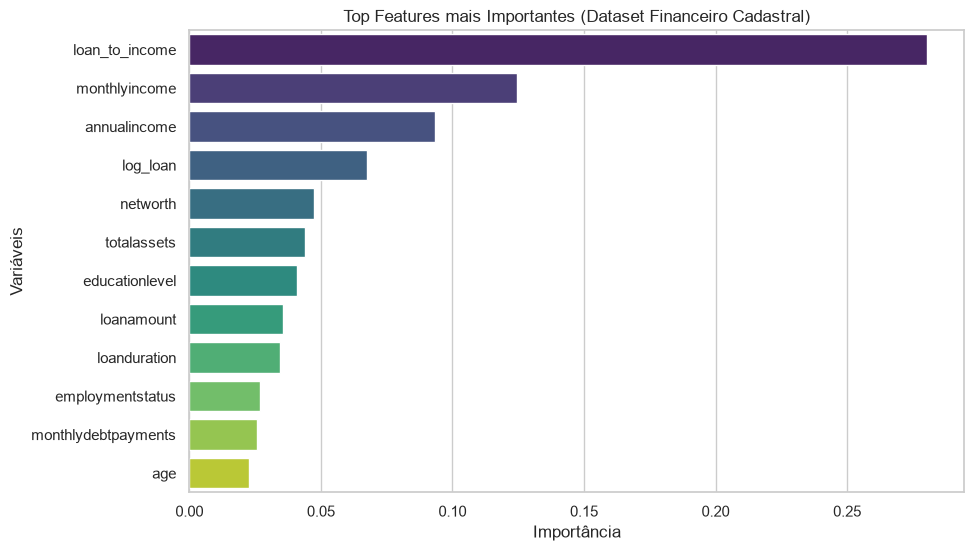

📊 Threshold Otimizado Aplicado: 0.5329

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Denied (0)       0.97      0.89      0.93      3044
Approved (1)       0.72      0.92      0.81       956

    accuracy                           0.90      4000
   macro avg       0.85      0.91      0.87      4000
weighted avg       0.91      0.90      0.90      4000



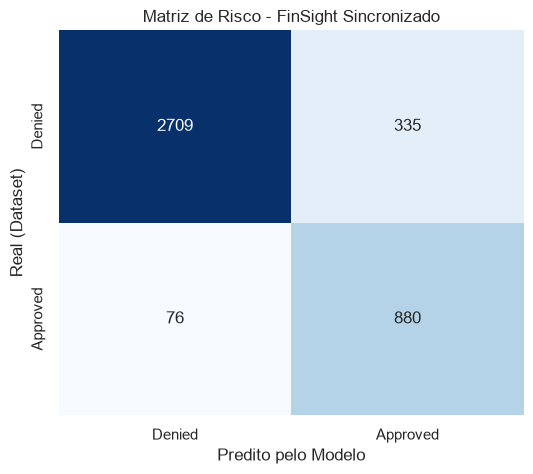

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Redefine a função localmente para garantir que o kernel use a versão correta
def feature_engineering_avancada_notebook(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()

    drop_features = [
        "applicationdate", "creditscore", "bankruptcyhistory", "previousloandefaults", 
        "paymenthistory", "lengthofcredithistory", "numberofopencreditlines", 
        "numberofcreditinquiries", "debttoincomeratio", "totaldebttoincomeratio",
        "baseinterestrate", "interestrate", "monthlyloanpayment", "riskscore",
        "loanapproved", "loan_approved", "loan_status"
    ]
    df.drop(columns=[c for c in drop_features if c in df.columns], inplace=True, errors="ignore")

    num_cols = ["age", "annualincome", "experience", "loanamount", "loanduration", 
                "numberofdependents", "monthlydebtpayments", "creditcardutilizationrate",
                "savingsaccountbalance", "checkingaccountbalance", "totalassets", 
                "totalliabilities", "monthlyincome", "jobtenure", "networth"]
    
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    if "annualincome" in df.columns and "loanamount" in df.columns:
        df["loan_to_income"] = df["loanamount"] / (df["annualincome"] + 1.0)
        df["log_income"] = np.log1p(df["annualincome"])
        df["log_loan"] = np.log1p(df["loanamount"])

    if "experience" in df.columns and "age" in df.columns:
        df["career_stability_ratio"] = df["experience"] / (df["age"] + 1.0)

    str_cols = df.select_dtypes(include=["object", "category"]).columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

    return df

# 2. Carrega os dados brutos e prepara o target
df_raw = pd.read_csv("data/processed/loan_approval_data.csv")
df_raw.columns = df_raw.columns.str.strip().str.lower()
target_col = "loanapproved" if "loanapproved" in df_raw.columns else "loan_status"

y = pd.to_numeric(df_raw[target_col], errors="coerce").fillna(0).astype(int)

# 3. Aplica a engenharia com todas as features de interação
df_features = feature_engineering_avancada_notebook(df_raw)
X = df_features.drop(columns=[target_col], errors="ignore")

# 4. Mantém a mesma divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Carrega o pipeline campeão
pipeline = joblib.load("artifacts/champion_model.pkl")

# --- A. FEATURE IMPORTANCE ---
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]

try:
    cat_transformer = preprocessor.named_transformers_["cat"]
    cat_cols_encoded = cat_transformer.get_feature_names_out() if hasattr(cat_transformer, "get_feature_names_out") else X.select_dtypes(include=["object", "category"]).columns
except:
    cat_cols_encoded = X.select_dtypes(include=["object", "category"]).columns

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
feature_names = list(num_cols) + list(cat_cols_encoded)

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    if len(importances) == len(feature_names):
        feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp.head(12), palette='viridis')
        plt.title("Top Features mais Importantes (Dataset Financeiro Cadastral)")
        plt.xlabel("Importância")
        plt.ylabel("Variáveis")
        plt.show()

# --- MATRIZ DE CONFUSÃO SINCRONIZADA COM O CHAMPION MODEL ---
test_proba = pipeline.predict_proba(X_test)[:, 1]

# Força o threshold exato obtido na otimização do train.py
best_threshold = 0.5329
y_pred = (test_proba >= best_threshold).astype(int)

print(f"📊 Threshold Otimizado Aplicado: {best_threshold}\n")
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=["Denied (0)", "Approved (1)"]))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Denied", "Approved"],
            yticklabels=["Denied", "Approved"])
plt.xlabel("Predito pelo Modelo")
plt.ylabel("Real (Dataset)")
plt.title("Matriz de Risco - FinSight Sincronizado")
plt.show()

## Fraude e Pix

In [ ]:
df_fraud = pd.read_parquet("data/processed/pix_fraud_sample.parquet")
df_fraud.columns

Index(['anomes', 'qtdepixcontestados', 'qtdecontestacoesaceitas',
       'qtdecontestacoesrejeitadas', 'qtdecontestacoesaceitasacada100mil',
       'qtdeusuarioscommarcacoesdefraude', 'qtdechavespixcommarcacoesdefraude',
       'valorpixcontestadosaceitos',
       'quantidadedevolvidaintegralmentepormeiodomed',
       'valorpixdevolvidosintegralmente',
       'quantidadedevolvidaparcialmentepormeiodomed',
       'valorpixdevolvidosparcialmente', 'valorpixresidualnaodevolvido',
       'quantidadedenaodevolvidossaldoinsuficiente',
       'valorpixnaodevolvidossaldoinsuficiente',
       'quantidadedenaodevolvidoscontaencerrada',
       'valornaodevolvidoscontaencerrada',
       'quantidadedenaodevolvidosmotivosdiversos',
       'valorpixnaodevolvidosmotivosdiversos', 'percentualdedevolucao',
       'qtdepixbloqueadoscautelarmenteeliberados',
       'valorpixbloqueadoscautelarmenteeliberados',
       'qtdepixbloqueadoscautelarmenteedevolvidos',
       'valorpixbloqueadoscautelarmenteedevol

In [ ]:
df_fraud.shape

(5, 24)

In [ ]:
df_pix = pd.read_parquet("data/processed/pix_transacoes_sample.parquet")
df_pix.columns

Index(['anomes', 'pag_pfpj', 'rec_pfpj', 'pag_regiao', 'rec_regiao',
       'pag_idade', 'rec_idade', 'formainiciacao', 'natureza', 'finalidade',
       'valor', 'quantidade'],
      dtype='object')

In [ ]:
finalidades = df_pix['finalidade'].unique()
print(finalidades)